## 1 · Setup & Data Loading

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE      = {"Low": "#5DADE2", "Medium": "#58D68D", "High": "#E74C3C"}
SPLIT_COLORS = {"train": "#2980B9", "devel": "#27AE60"}

DATA_DIR   = "preprocessed_data"
train_df   = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
devel_df   = pd.read_csv(os.path.join(DATA_DIR, "devel.csv"))
test_df    = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
norm_stats = pd.read_csv(os.path.join(DATA_DIR, "norm_stats.csv"), index_col=0)
thresholds = pd.read_csv(os.path.join(DATA_DIR, "class_thresholds.csv"))

P33 = thresholds.loc[0, "value"]
P66 = thresholds.loc[1, "value"]

RAW_FEATS  = ["BPM_mean","BPM_median","BPM_mode",
              "ECG_mean","ECG_median","ECG_mode",
              "resp_mean","resp_median","resp_mode"]
NORM_FEATS = [f"{c}_norm" for c in RAW_FEATS]
LABEL_COLS = ["label_mean","label_median","label_mode"]
CLASS_COLS = ["class_mean","class_median","class_mode"]

print("Loaded successfully.")
print(f"  Train : {train_df.shape[0]:>5} windows, {train_df.shape[1]} columns")
print(f"  Devel : {devel_df.shape[0]:>5} windows, {devel_df.shape[1]} columns")
print(f"  Test  : {test_df.shape[0]:>5} windows, {test_df.shape[1]} columns")


Loaded successfully.
  Train :  4105 windows, 28 columns
  Devel :  1413 windows, 28 columns
  Test  :  1408 windows, 28 columns


## 2 · Dataset Overview

In [2]:
print("Column names and dtypes (train):")
print(train_df.dtypes.to_string())


Column names and dtypes (train):
subject_id            int64
window_id             int64
start_timestamp       int64
end_timestamp         int64
BPM_mean            float64
BPM_median          float64
BPM_mode            float64
ECG_mean            float64
ECG_median          float64
ECG_mode            float64
resp_mean           float64
resp_median         float64
resp_mode           float64
BPM_mean_norm       float64
BPM_median_norm     float64
BPM_mode_norm       float64
ECG_mean_norm       float64
ECG_median_norm     float64
ECG_mode_norm       float64
resp_mean_norm      float64
resp_median_norm    float64
resp_mode_norm      float64
label_mean          float64
label_median        float64
label_mode          float64
class_mean           object
class_median         object
class_mode           object


In [3]:
def null_summary(df, name):
    s = df.isnull().sum()
    s = s[s > 0]
    if len(s) == 0:
        print(f"[{name}]  No missing values.")
    else:
        print(f"[{name}]  Missing values:")
        print(s.to_string())

for name, df in [("train", train_df), ("devel", devel_df), ("test", test_df)]:
    null_summary(df, name)


[train]  No missing values.
[devel]  No missing values.
[test]  Missing values:
label_mean      1408
label_median    1408
label_mode      1408
class_mean      1408
class_median    1408
class_mode      1408


In [4]:
train_df.head()

,subject_id,window_id,start_timestamp,end_timestamp,BPM_mean,BPM_median,BPM_mode,ECG_mean,ECG_median,ECG_mode,...,ECG_mode_norm,resp_mean_norm,resp_median_norm,resp_mode_norm,label_mean,label_median,label_mode,class_mean,class_median,class_mode
0,1,0,500,3000,75.781991,74.874773,69.372357,-0.022181,-0.013669,-0.071821,...,0.231069,0.311733,0.275672,0.745248,0.084417,0.08070,0.0370,High,High,High
1,1,1,3500,6000,83.857146,83.810223,80.548999,-0.014035,-0.011478,-0.037429,...,0.506014,0.088487,0.089509,0.667063,0.257317,0.25640,0.1702,High,High,High
2,1,2,6500,9000,84.447378,84.909571,82.848332,-0.022113,-0.017114,-0.067411,...,0.266325,-0.739620,-0.222249,-1.845566,0.460000,0.46280,0.3823,High,High,High
3,1,3,9500,12000,91.158031,90.801164,88.107476,-0.005067,-0.005451,-0.061052,...,0.317161,-0.213865,0.354209,-1.354842,0.594050,0.59770,0.5535,High,High,High
4,1,4,12500,15000,79.753796,78.987457,72.270204,-0.004790,0.004428,-0.059785,...,0.327290,0.249360,0.250973,0.351558,0.638400,0.63965,0.6325,High,High,High


In [5]:
train_df[RAW_FEATS].describe().round(4)

,BPM_mean,BPM_median,BPM_mode,ECG_mean,ECG_median,ECG_mode,resp_mean,resp_median,resp_mode
count,4105.0000,4105.0000,4105.0000,4105.0000,4105.0000,4105.0000,4105.0000,4105.0000,4105.0000
mean,99.2510,99.0985,94.7063,-0.0029,-0.0028,-0.1007,-0.0080,0.0065,-1.6600
std,21.0743,21.2110,21.1109,0.0759,0.0782,0.1251,1.3359,1.5162,1.9976
min,57.7915,57.4726,35.2941,-0.6929,-0.8339,-1.3598,-6.8382,-6.8193,-9.7668
25%,83.1453,82.9794,78.7402,-0.0196,-0.0189,-0.1265,-0.4426,-0.4547,-2.7467
50%,94.7227,94.7925,90.2126,-0.0017,-0.0001,-0.0640,0.0068,0.0275,-0.9782
75%,115.3666,115.2641,110.2941,0.0148,0.0172,-0.0305,0.4484,0.5581,-0.2146
max,158.2329,158.5839,156.4711,1.1483,1.0899,0.5743,6.1916,6.3698,3.8758


## 3 · Raw Feature Distributions

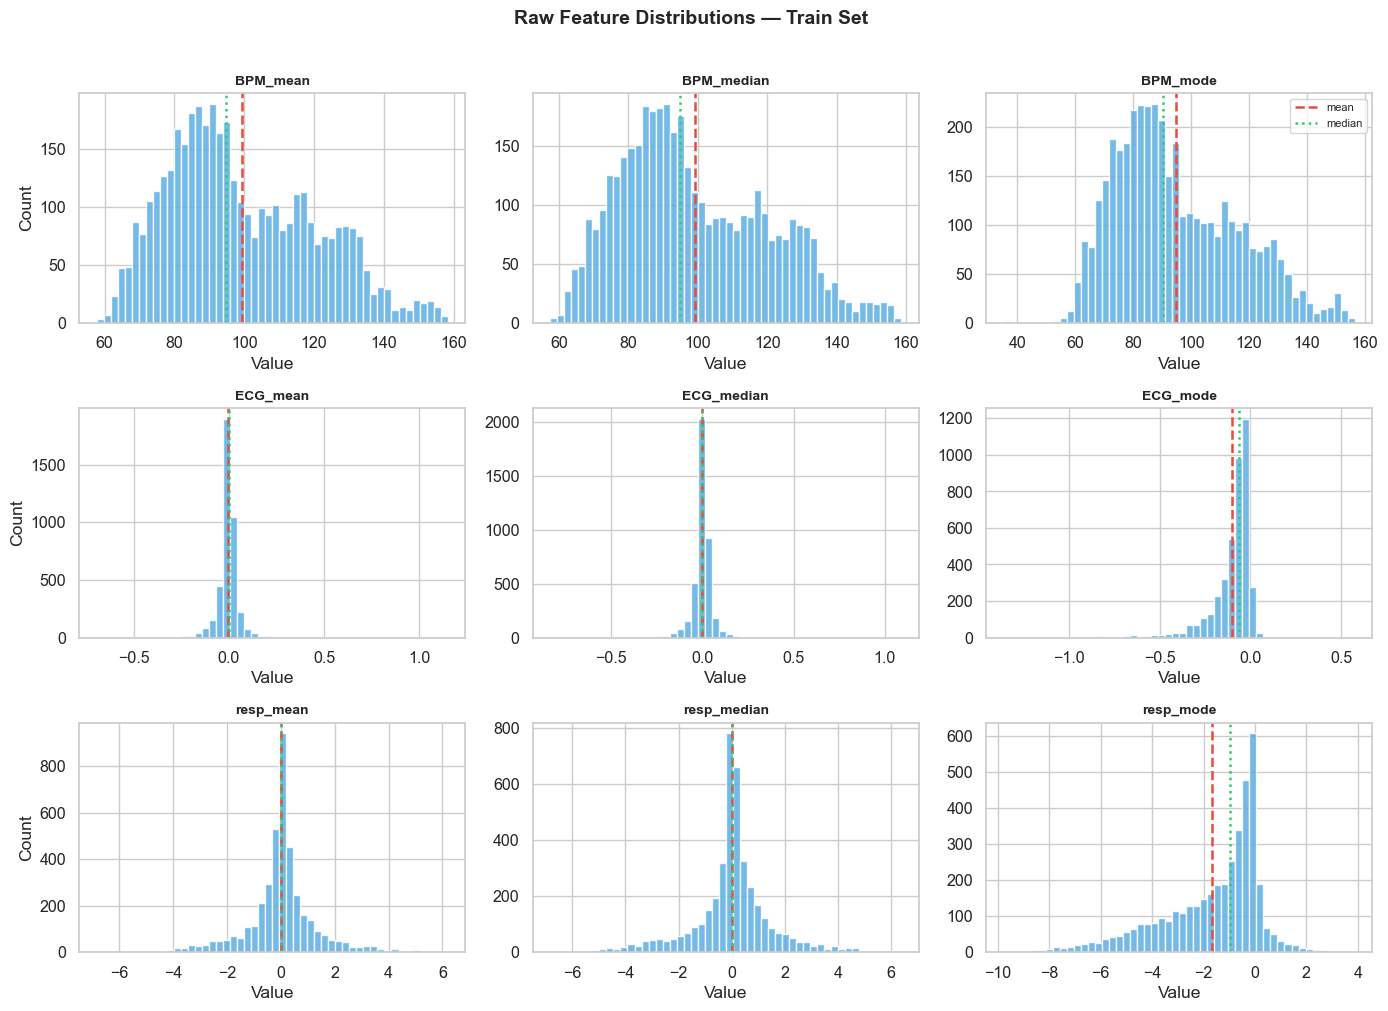

In [8]:
signals = ["BPM", "ECG", "resp"]
stats_  = ["mean", "median", "mode"]

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
fig.suptitle("Raw Feature Distributions — Train Set", fontsize=14, fontweight="bold", y=1.01)

for r, sig in enumerate(signals):
    for c, stat in enumerate(stats_):
        col = f"{sig}_{stat}"
        ax  = axes[r][c]
        ax.hist(train_df[col], bins=50, color="#5DADE2", edgecolor="white", alpha=0.85)
        ax.axvline(train_df[col].mean(),   color="#E74C3C", lw=1.8, ls="--", label="mean")
        ax.axvline(train_df[col].median(), color="#2ECC71", lw=1.8, ls=":",  label="median")
        ax.set_title(col, fontsize=10, fontweight="bold")
        ax.set_xlabel("Value")
        ax.set_ylabel("Count" if c == 0 else "")
        if r == 0 and c == 2:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## 4 · Label Distribution & Threshold Visualisation

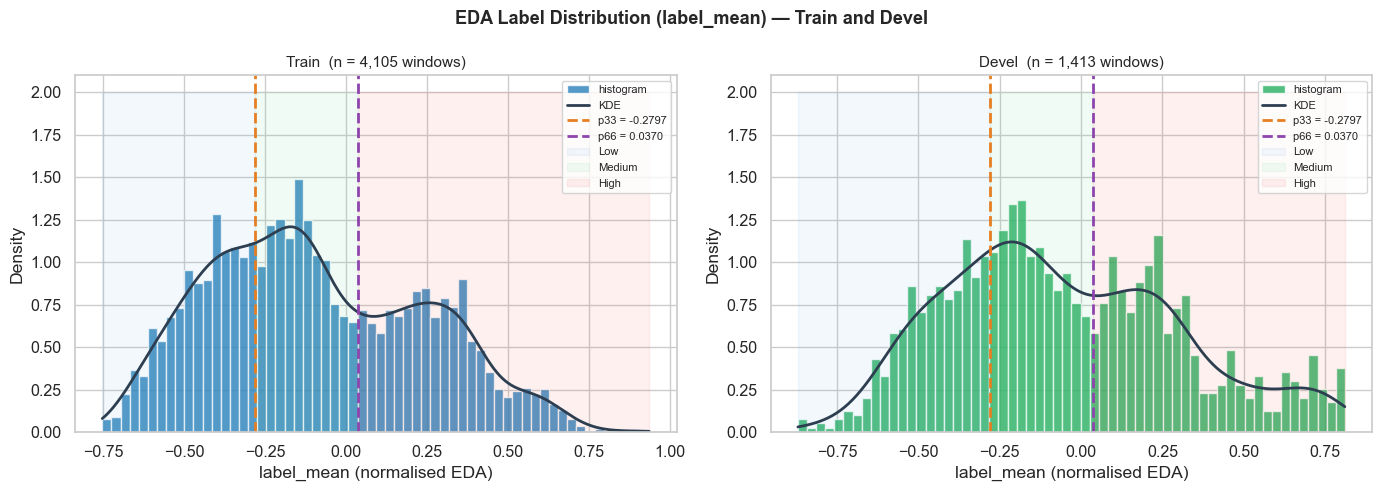

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("EDA Label Distribution (label_mean) — Train and Devel", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("Train", train_df), ("Devel", devel_df)]):
    col = df["label_mean"].dropna()
    ax.hist(col, bins=60, color=SPLIT_COLORS[name.lower()],
            edgecolor="white", alpha=0.8, density=True, label="histogram")
    kde_x = np.linspace(col.min(), col.max(), 400)
    ax.plot(kde_x, stats.gaussian_kde(col)(kde_x), color="#2C3E50", lw=2, label="KDE")
    ax.axvline(P33, color="#E67E22", lw=2, ls="--", label=f"p33 = {P33:.4f}")
    ax.axvline(P66, color="#8E44AD", lw=2, ls="--", label=f"p66 = {P66:.4f}")
    ax.fill_betweenx([0, 2], col.min(), P33, alpha=0.08, color="#5DADE2", label="Low")
    ax.fill_betweenx([0, 2], P33, P66,  alpha=0.08, color="#58D68D", label="Medium")
    ax.fill_betweenx([0, 2], P66, col.max(), alpha=0.08, color="#E74C3C", label="High")
    ax.set_ylim(0)
    ax.set_title(f"{name}  (n = {len(col):,} windows)", fontsize=11)
    ax.set_xlabel("label_mean (normalised EDA)"); ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()


## 5 · Arousal Class Distribution

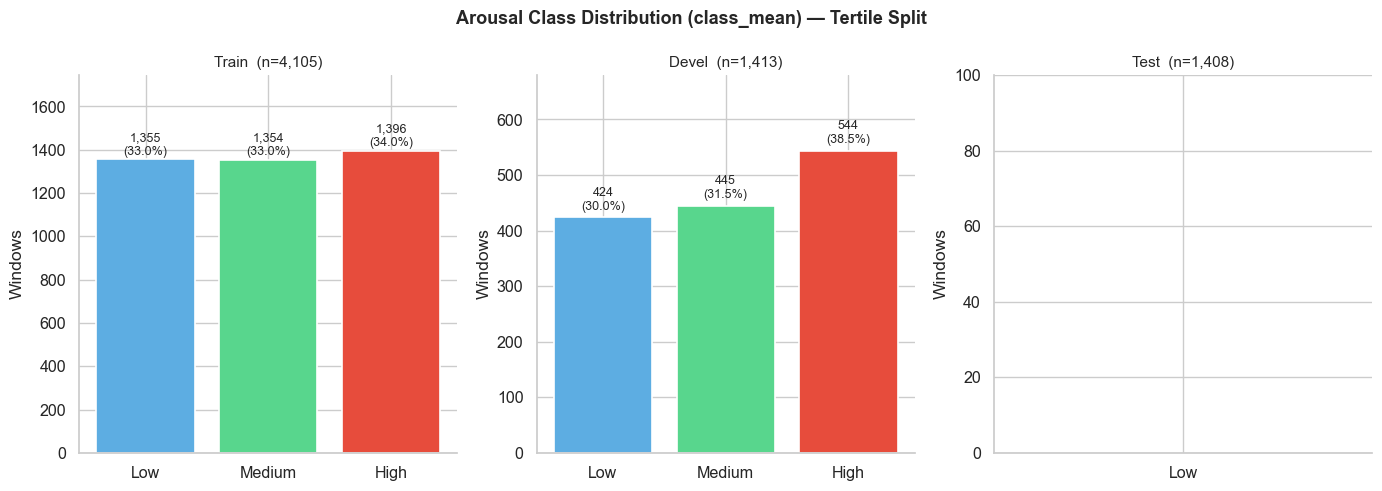

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Arousal Class Distribution (class_mean) — Tertile Split", fontsize=13, fontweight="bold")

for ax, (name, df) in zip(axes, [("Train", train_df), ("Devel", devel_df), ("Test", test_df)]):
    counts = df["class_mean"].value_counts().reindex(["Low", "Medium", "High"])
    bars = ax.bar(counts.index, counts.values,
                  color=[PALETTE[c] for c in counts.index], edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, counts.values):
        if pd.notna(val) and val > 0:
            pct = val / counts.sum() * 100
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                    f"{int(val):,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{name}  (n={len(df):,})", fontsize=11)
    ax.set_ylabel("Windows")
    ax.set_ylim(0, max(counts.fillna(0).max() * 1.25, 100))
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


## 6 · Normalised Feature Distributions

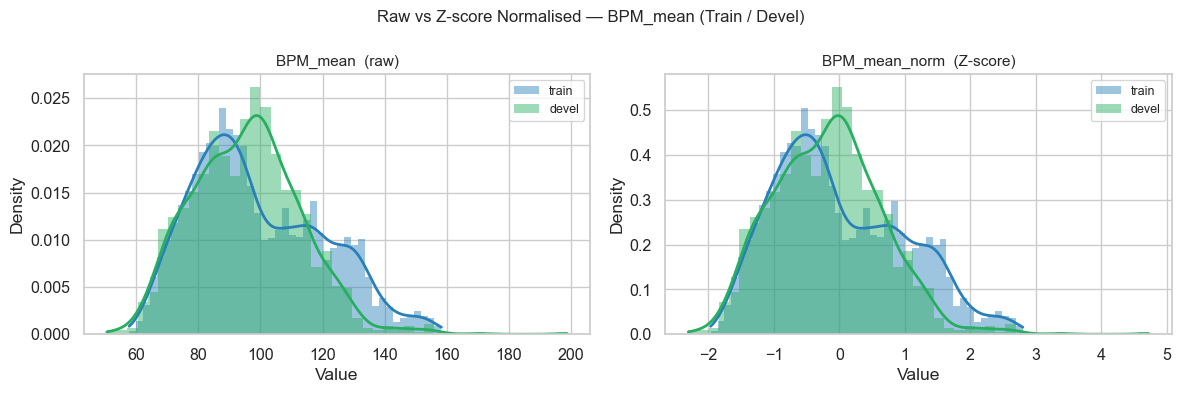

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, title in zip(axes,
                           ["BPM_mean", "BPM_mean_norm"],
                           ["BPM_mean  (raw)", "BPM_mean_norm  (Z-score)"]):
    for name, df, colour in [("train", train_df, "#2980B9"), ("devel", devel_df, "#27AE60")]:
        vals = df[col].dropna()
        ax.hist(vals, bins=45, alpha=0.45, color=colour, edgecolor="none", density=True, label=name)
        kde_x = np.linspace(vals.min(), vals.max(), 300)
        ax.plot(kde_x, stats.gaussian_kde(vals)(kde_x), color=colour, lw=2)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.suptitle("Raw vs Z-score Normalised — BPM_mean (Train / Devel)", fontsize=12)
plt.tight_layout()
plt.show()


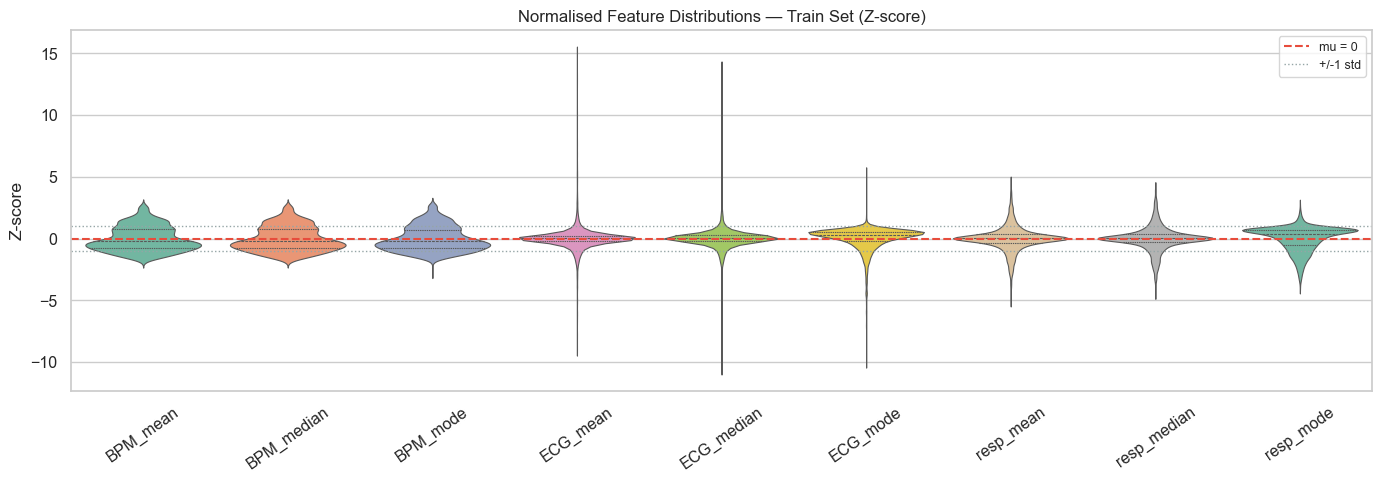

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))
melted = train_df[NORM_FEATS].melt(var_name="feature", value_name="z_score")
melted["feature"] = melted["feature"].str.replace("_norm","")
sns.violinplot(data=melted, x="feature", y="z_score", ax=ax,
               inner="quartile", palette="Set2", linewidth=0.8)
ax.axhline(0,  color="#E74C3C", lw=1.5, ls="--", label="mu = 0")
ax.axhline( 1, color="#95A5A6", lw=1, ls=":")
ax.axhline(-1, color="#95A5A6", lw=1, ls=":", label="+/-1 std")
ax.set_title("Normalised Feature Distributions — Train Set (Z-score)", fontsize=12)
ax.set_xlabel(""); ax.set_ylabel("Z-score")
ax.tick_params(axis="x", rotation=35)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 7 · Correlation Analysis

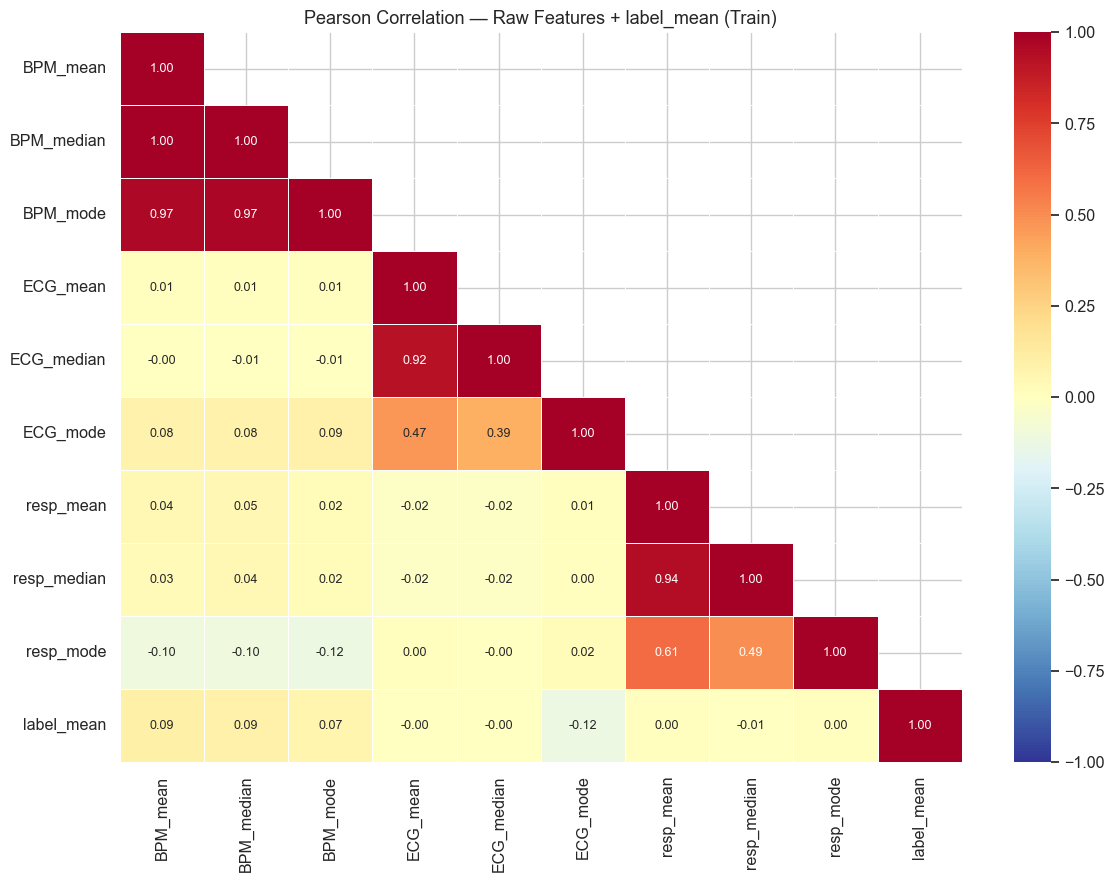

In [18]:
cols_for_corr = RAW_FEATS + ["label_mean"]
corr = train_df[cols_for_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor="white", annot_kws={"size": 9})
ax.set_title("Pearson Correlation — Raw Features + label_mean (Train)", fontsize=13)
plt.tight_layout()
plt.show()


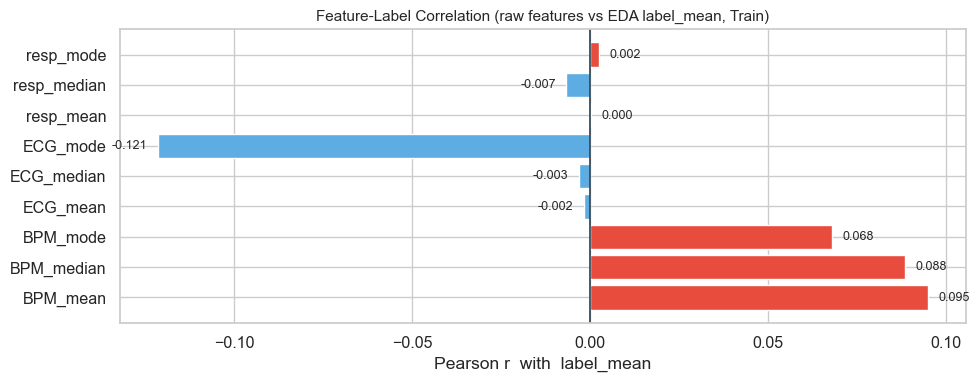

In [19]:
feat_label_corr = train_df[RAW_FEATS + ["label_mean"]].corr()["label_mean"].drop("label_mean")

fig, ax = plt.subplots(figsize=(10, 4))
colours = ["#E74C3C" if v > 0 else "#5DADE2" for v in feat_label_corr.values]
ax.barh(feat_label_corr.index, feat_label_corr.values, color=colours, edgecolor="white")
ax.axvline(0, color="#2C3E50", lw=1.2)
ax.set_xlabel("Pearson r  with  label_mean")
ax.set_title("Feature-Label Correlation (raw features vs EDA label_mean, Train)", fontsize=11)
for i, v in enumerate(feat_label_corr.values):
    ax.text(v + (0.003 if v >= 0 else -0.003), i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()


## 8 · Feature Distributions by Arousal Class

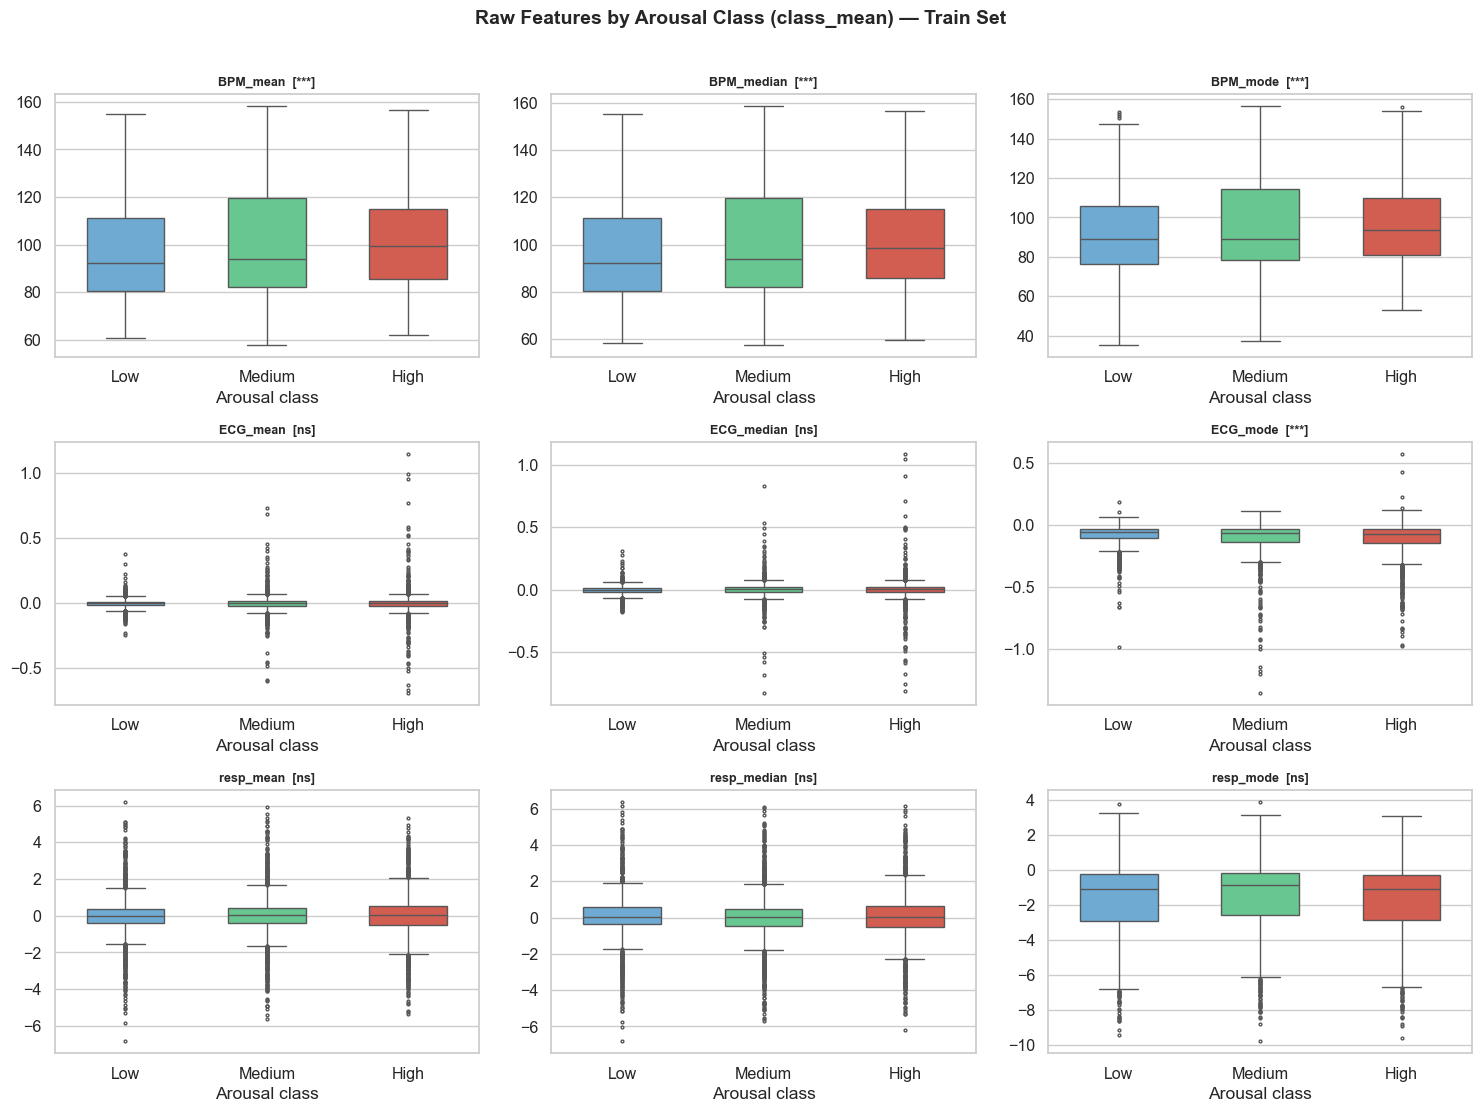

* p<0.05  ** p<0.01  *** p<0.001  ns = not significant  (one-way ANOVA)


In [21]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle("Raw Features by Arousal Class (class_mean) — Train Set",
             fontsize=14, fontweight="bold", y=1.01)

for r, sig in enumerate(["BPM", "ECG", "resp"]):
    for c, stat in enumerate(["mean", "median", "mode"]):
        col = f"{sig}_{stat}"
        ax  = axes[r][c]
        sns.boxplot(data=train_df, x="class_mean", y=col, ax=ax,
                    order=["Low","Medium","High"], palette=PALETTE, width=0.55, fliersize=2)
        groups  = [train_df.loc[train_df["class_mean"]==cls, col].dropna()
                   for cls in ["Low","Medium","High"]]
        f_stat, p_val = stats.f_oneway(*groups)
        sig_marker = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "ns"))
        ax.set_title(f"{col}  [{sig_marker}]", fontsize=9, fontweight="bold")
        ax.set_xlabel("Arousal class"); ax.set_ylabel("")

plt.tight_layout()
plt.show()
print("* p<0.05  ** p<0.01  *** p<0.001  ns = not significant  (one-way ANOVA)")


In [22]:
class_means = train_df.groupby("class_mean")[RAW_FEATS].mean().round(4)
print("Mean feature values per arousal class (train):")
class_means


Mean feature values per arousal class (train):


,BPM_mean,BPM_median,BPM_mode,ECG_mean,ECG_median,ECG_mode,resp_mean,resp_median,resp_mode
class_mean,,,,,,,,,
High,101.2294,100.9074,95.9943,-0.0017,-0.0029,-0.1147,-0.0133,0.0108,-1.7018
Low,96.2088,96.1764,92.2961,-0.0022,-0.0029,-0.0796,-0.0150,0.0338,-1.7220
Medium,100.2556,100.1577,95.7903,-0.0048,-0.0024,-0.1074,0.0045,-0.0252,-1.5549


## 9 · Subject-Level Analysis

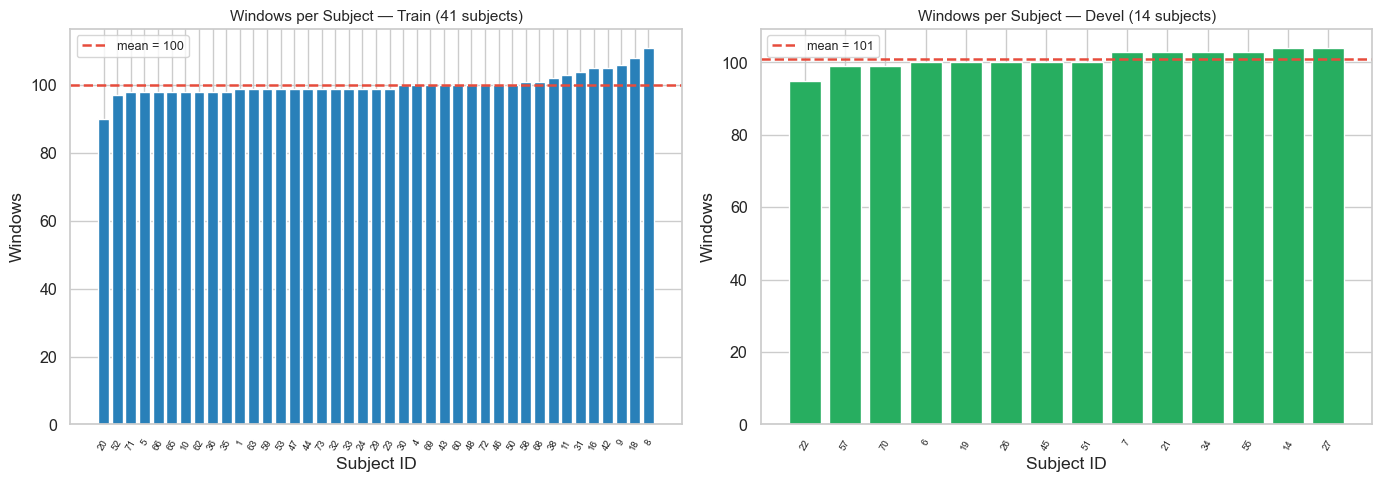

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [("Train (41 subjects)", train_df), ("Devel (14 subjects)", devel_df)]):
    wps = df.groupby("subject_id")["window_id"].count().sort_values()
    colour = SPLIT_COLORS["train"] if "Train" in name else SPLIT_COLORS["devel"]
    ax.bar(wps.index.astype(str), wps.values, color=colour, edgecolor="white")
    ax.axhline(wps.mean(), color="#E74C3C", lw=1.8, ls="--", label=f"mean = {wps.mean():.0f}")
    ax.set_title(f"Windows per Subject — {name}", fontsize=11)
    ax.set_xlabel("Subject ID"); ax.set_ylabel("Windows")
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


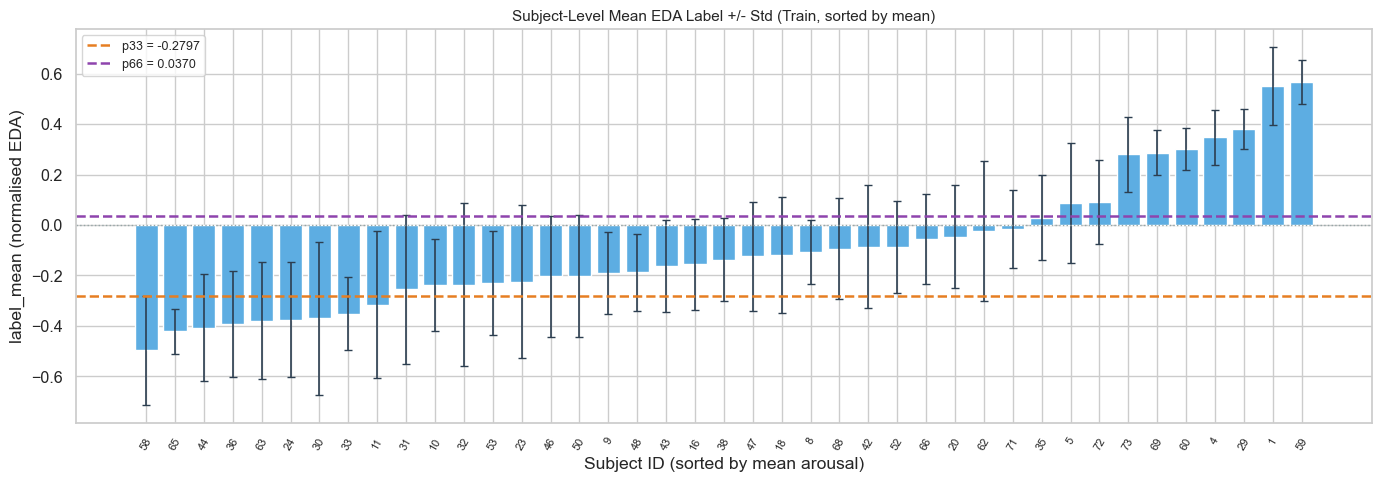

In [25]:
subj_stats = train_df.groupby("subject_id")["label_mean"].agg(["mean","std","min","max"]).round(4)
subj_stats = subj_stats.sort_values("mean")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(subj_stats.index.astype(str), subj_stats["mean"], color="#5DADE2", edgecolor="white")
ax.errorbar(range(len(subj_stats)), subj_stats["mean"],
            yerr=subj_stats["std"], fmt="none", color="#2C3E50", lw=1.2, capsize=3)
ax.axhline(P33, color="#E67E22", lw=1.8, ls="--", label=f"p33 = {P33:.4f}")
ax.axhline(P66, color="#8E44AD", lw=1.8, ls="--", label=f"p66 = {P66:.4f}")
ax.axhline(0,   color="#95A5A6", lw=1, ls=":")
ax.set_title("Subject-Level Mean EDA Label +/- Std (Train, sorted by mean)", fontsize=11)
ax.set_xlabel("Subject ID (sorted by mean arousal)"); ax.set_ylabel("label_mean (normalised EDA)")
ax.tick_params(axis="x", rotation=60, labelsize=8); ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


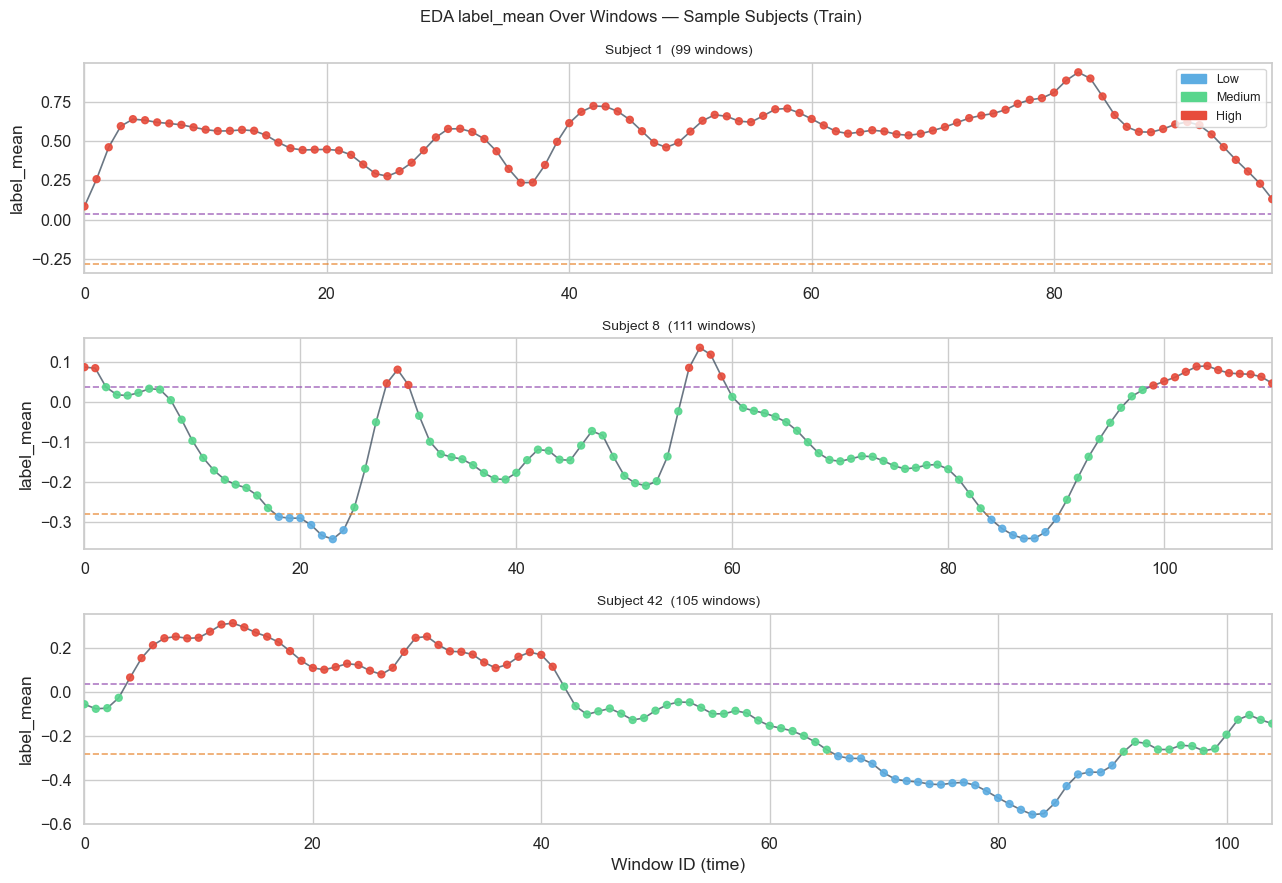

In [27]:
sample_subjects = [1, 8, 42]
fig, axes = plt.subplots(len(sample_subjects), 1, figsize=(13, 9), sharex=False)
fig.suptitle("EDA label_mean Over Windows — Sample Subjects (Train)", fontsize=12)

colours_map = {"Low": "#5DADE2", "Medium": "#58D68D", "High": "#E74C3C"}
for ax, sid in zip(axes, sample_subjects):
    subj = train_df[train_df["subject_id"] == sid].copy()
    ax.plot(subj["window_id"], subj["label_mean"], color="#2C3E50", lw=1.2, alpha=0.7)
    ax.scatter(subj["window_id"], subj["label_mean"],
               c=subj["class_mean"].map(colours_map), s=25, zorder=5, alpha=0.9)
    ax.axhline(P33, color="#E67E22", lw=1.2, ls="--", alpha=0.7)
    ax.axhline(P66, color="#8E44AD", lw=1.2, ls="--", alpha=0.7)
    ax.set_ylabel("label_mean")
    ax.set_title(f"Subject {sid}  ({len(subj)} windows)", fontsize=10)
    ax.set_xlim(0, subj["window_id"].max())

axes[-1].set_xlabel("Window ID (time)")
from matplotlib.patches import Patch
handles = [Patch(color=v, label=k) for k, v in colours_map.items()]
axes[0].legend(handles=handles, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()


## 10 · Train vs Devel Comparison

In [29]:
print("Kolmogorov-Smirnov test — Train vs Devel (are distributions the same?)")
print(f"{'Feature':<22} {'KS stat':>8} {'p-value':>12} {'Conclusion':>22}")
print("-" * 68)
for col in RAW_FEATS:
    ks, pv = stats.ks_2samp(train_df[col].dropna(), devel_df[col].dropna())
    conclusion = "same distribution" if pv > 0.05 else "DIFFERENT (p<0.05)"
    print(f"{col:<22} {ks:>8.4f} {pv:>12.4f}   {conclusion}")


Kolmogorov-Smirnov test — Train vs Devel (are distributions the same?)
Feature                 KS stat      p-value             Conclusion
--------------------------------------------------------------------
BPM_mean                 0.1358       0.0000   DIFFERENT (p<0.05)
BPM_median               0.1350       0.0000   DIFFERENT (p<0.05)
BPM_mode                 0.1369       0.0000   DIFFERENT (p<0.05)
ECG_mean                 0.1045       0.0000   DIFFERENT (p<0.05)
ECG_median               0.1054       0.0000   DIFFERENT (p<0.05)
ECG_mode                 0.0551       0.0032   DIFFERENT (p<0.05)
resp_mean                0.0573       0.0019   DIFFERENT (p<0.05)
resp_median              0.0683       0.0001   DIFFERENT (p<0.05)
resp_mode                0.0686       0.0001   DIFFERENT (p<0.05)


## 11 · Outlier Detection

In [30]:
print("Outlier windows per feature (|z| > 3) — Train set")
print(f"Total train windows: {len(train_df)}")
print()
print(f"{'Feature (norm)':<25} {'|z|>3 count':>12} {'%':>8}")
print("-" * 48)
for col in NORM_FEATS:
    n_out = (train_df[col].abs() > 3).sum()
    print(f"{col:<25} {n_out:>12,} {n_out/len(train_df)*100:>7.2f}%")
print()
any_outlier = (train_df[NORM_FEATS].abs() > 3).any(axis=1).sum()
print(f"Windows with at least one |z|>3 feature: {any_outlier:,}  ({any_outlier/len(train_df)*100:.2f}%)")


Outlier windows per feature (|z| > 3) — Train set
Total train windows: 4105

Feature (norm)             |z|>3 count        %
------------------------------------------------
BPM_mean_norm                        0    0.00%
BPM_median_norm                      0    0.00%
BPM_mode_norm                        0    0.00%
ECG_mean_norm                       71    1.73%
ECG_median_norm                     70    1.71%
ECG_mode_norm                       86    2.10%
resp_mean_norm                      75    1.83%
resp_median_norm                    78    1.90%
resp_mode_norm                      41    1.00%

Windows with at least one |z|>3 feature: 261  (6.36%)


## 12 · Key Findings Summary

| Finding | Detail |
|---------|--------|
| **Dataset size** | 6,926 total windows (4,105 train / 1,413 devel / 1,408 test) |
| **Window length** | 3 seconds = 6 rows at 2 Hz — all subjects have 90-111 windows |
| **Missing values** | None in features; labels are NaN for test (by design) |
| **Label range (train)** | -0.75 to +0.94 (normalised EDA) |
| **Class balance** | Low: 33.0% · Medium: 33.0% · High: 34.0% — near-perfect tertile split |
| **Normalisation** | Train mean = 0.000, std = 1.000; devel/test shift slightly (expected) |
| **BPM range** | ~60-160 bpm, mean ~99 bpm |
| **ECG range** | Near-zero mean (~-0.003 mV) |
| **resp range** | High variance (sigma~2); resp_mode has large spread |
| **Feature-label correlation** | Weak for most features (|r| < 0.15) — arousal is multivariate |
| **Subject variability** | Large inter-subject EDA differences (train: min~-0.47, max~0.25) |
| **Outliers (|z|>3)** | < 2% of windows per feature — no systematic noise detected |


In [33]:
summary_rows = []
for name, df in [("Train", train_df), ("Devel", devel_df), ("Test", test_df)]:
    row = {
        "Split":           name,
        "Subjects":        df["subject_id"].nunique(),
        "Windows":         len(df),
        "Win/Subj (mean)": round(df.groupby("subject_id").size().mean(), 1),
    }
    if df["label_mean"].notna().any():
        row["label_mean mu"] = round(df["label_mean"].mean(), 4)
        row["label_mean sd"] = round(df["label_mean"].std(),  4)
        for cls in ["Low","Medium","High"]:
            row[f"% {cls}"] = f"{(df['class_mean']==cls).mean()*100:.1f}%"
    else:
        row["label_mean mu"] = "N/A"; row["label_mean sd"] = "N/A"
        for cls in ["Low","Medium","High"]: row[f"% {cls}"] = "N/A"
    summary_rows.append(row)

pd.DataFrame(summary_rows).set_index("Split")


,Subjects,Windows,Win/Subj (mean),label_mean mu,label_mean sd,% Low,% Medium,% High
Split,,,,,,,,
Train,41,4105,100.1,-0.0929,0.3288,33.0%,33.0%,34.0%
Devel,14,1413,100.9,-0.0562,0.3582,30.0%,31.5%,38.5%
Test,14,1408,100.6,N/A,N/A,N/A,N/A,N/A
